# V42 Expanded: LQ45 AI Strategy with Comprehensive Visualization

**Objective**: This notebook extends the V42 Hybrid Strategy by adding detailed visualizations to better understand performance, risk, and model behavior.

### Visualizations Included:
1. **Performance Comparison**: Cumulative Wealth (Hybrid vs Static vs IHSG).
2. **Drawdown Analysis**: Analyzing peak-to-trough declines.
3. **Feature Importance**: Which market indicators drive the AI's decisions?
4. **Signal Probability Distribution**: How confident is the AI in different market phases?
5. **Monthly Returns Heatmap**: Seasonality and monthly performance breakdown.


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")


Data Loaded: 712 rows


In [2]:
# --- 2. Feature Engineering & AI Model ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# Calculate Trend Signal for Override (Price > MA50)
trend_bullish = (market_price > ma50).astype(int)

# TARGET: MA Slope Direction
target = (ma5.shift(-1) > ma5).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)
trend_bullish = trend_bullish.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

opt_t = 0.60
print(f"[Strategy] Using Base Threshold: {opt_t:.2f} with MA50 Override")


[Strategy] Using Base Threshold: 0.60 with MA50 Override


In [3]:
# --- 3. Simulation Logic (Hybrid) ---

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    sigma += np.eye(len(sigma)) * 1e-4 
    try:
        res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                       [1./len(mu)]*len(mu), method='SLSQP', 
                       bounds=tuple((0, 1) for _ in range(len(mu))), 
                       constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
        return dict(zip(selected_returns.columns, res.x)) if res.success else {}
    except:
        return {}

def run_simulation_hybrid(strategy_type, test_dates, returns, ai_probs=None, trend_signal=None, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    state_history = []
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        current_state = "Neutral"
        weights = {}

        if strategy_type == 'AI Hybrid':
            prob = ai_probs.loc[date]
            is_trend_up = trend_signal.loc[date] == 1
            
            # HYBRID LOGIC:
            # Go to Cash ONLY if AI is scared (< T) AND Trend is Down (< MA50).
            # If Trend is UP, stay invested regardless of AI.
            is_risk_off = (prob < threshold) and (not is_trend_up)
            
            if is_risk_off: 
                weights = {'CASH': 1.0}
                current_state = "Cash (AI+Trend)"
            else:
                # Risk On: Markowitz on all assets (No Graph Filter)
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                weights = optimize_markowitz(window_rets[valid_assets])
                current_state = "Invested (Trend/AI)"
                
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                static_weights = optimize_markowitz(window_rets[valid_assets])
            weights = static_weights
            current_state = "Static"
        
        state_history.append(current_state)
        
        # Transaction Costs
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history, 'State': state_history + [state_history[-1]]}, index=dates)


In [4]:
# --- 4. Models & Benchmark Execution ---
ai_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)
test_trend = trend_bullish.loc[X_test.index]

print("Running AI Hybrid Strategy...")
hybrid_res = run_simulation_hybrid('AI Hybrid', X_test.index, returns, ai_probs, test_trend, threshold=opt_t)

print("Running Markowitz Static...")
static_res = run_simulation_hybrid('Markowitz Static', X_test.index, returns)

print("Calculating IHSG Benchmark...")
ihsg_ret = market_return.loc[X_test.index]
ihsg_price = (1 + ihsg_ret).cumprod() * 100


Running AI Hybrid Strategy...
Running Markowitz Static...
Calculating IHSG Benchmark...


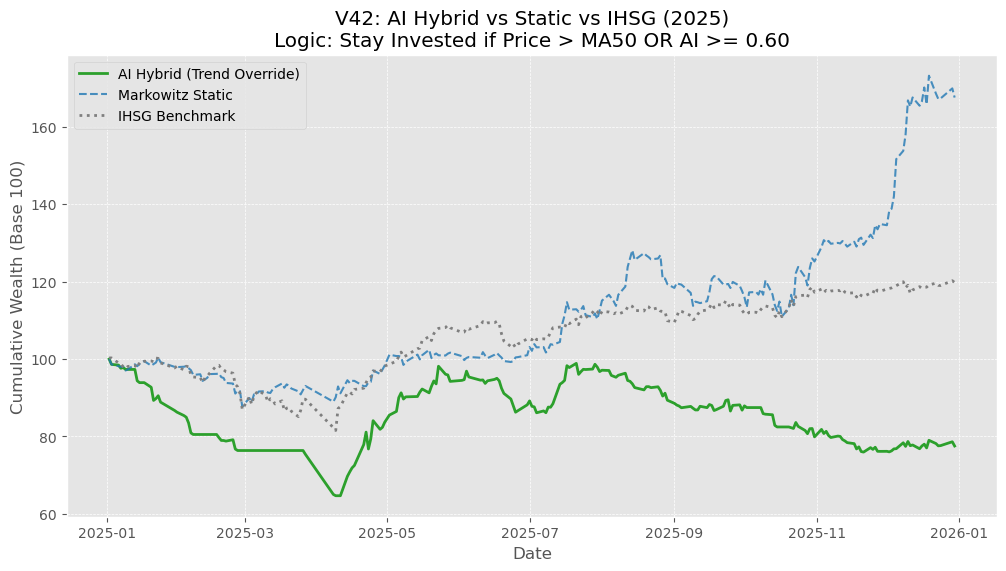

In [5]:
# --- Visualization 1: Performance Comparison ---
plt.figure(figsize=(12, 6))
plt.plot(hybrid_res['Portfolio_Value'], label=f'AI Hybrid (Trend Override)', color='#2ca02c', linewidth=2)
plt.plot(static_res['Portfolio_Value'], label='Markowitz Static', color='#1f77b4', linestyle='--', alpha=0.8)
plt.plot(ihsg_price, label='IHSG Benchmark', color='#7f7f7f', linestyle=':', linewidth=2)

plt.title(f'V42: AI Hybrid vs Static vs IHSG (2025)\nLogic: Stay Invested if Price > MA50 OR AI >= {opt_t:.2f}')
plt.ylabel('Cumulative Wealth (Base 100)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('v42_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


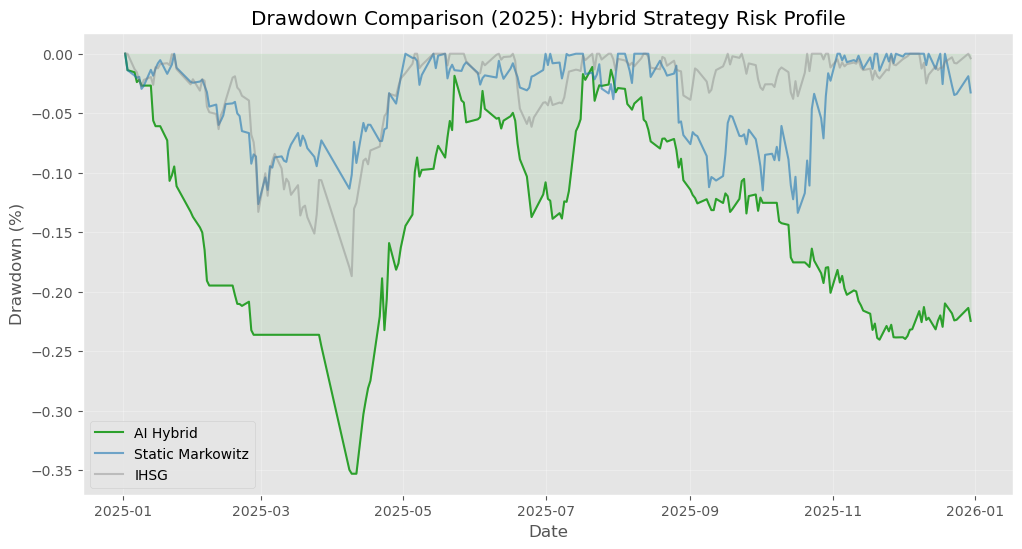

In [6]:
# --- Visualization 2: Drawdown Analysis ---
def calculate_drawdown(series):
    return (series / series.cummax()) - 1

dd_hybrid = calculate_drawdown(hybrid_res['Portfolio_Value'])
dd_static = calculate_drawdown(static_res['Portfolio_Value'])
dd_ihsg = calculate_drawdown(ihsg_price)

plt.figure(figsize=(12, 6))
plt.plot(dd_hybrid, label='AI Hybrid', color='#2ca02c')
plt.plot(dd_static, label='Static Markowitz', color='#1f77b4', alpha=0.6)
plt.plot(dd_ihsg, label='IHSG', color='#7f7f7f', alpha=0.4)
plt.fill_between(dd_hybrid.index, dd_hybrid, 0, color='#2ca02c', alpha=0.1)

plt.title('Drawdown Comparison (2025): Hybrid Strategy Risk Profile')
plt.ylabel('Drawdown (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('v42_drawdown_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


<Figure size 1000x600 with 0 Axes>

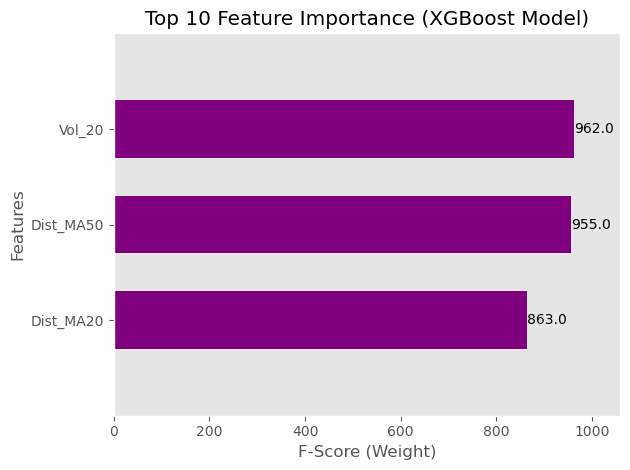

In [7]:
# --- Visualization 3: Feature Importance (XGBoost) ---
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10, height=0.6, grid=False, importance_type='weight', color='purple')
plt.title('Top 10 Feature Importance (XGBoost Model)')
plt.xlabel('F-Score (Weight)')
plt.tight_layout()
plt.savefig('v42_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


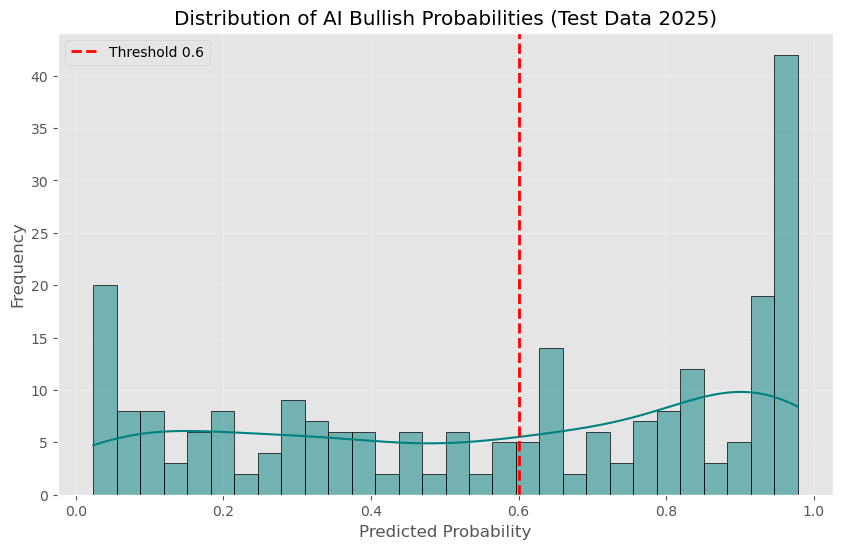

In [8]:
# --- Visualization 4: AI Signal Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(xgb_model.predict_proba(X_test)[:, 1], bins=30, kde=True, color='teal', edgecolor='black')
plt.axvline(opt_t, color='red', linestyle='--', linewidth=2, label=f'Threshold {opt_t}')
plt.title('Distribution of AI Bullish Probabilities (Test Data 2025)')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('v42_signal_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


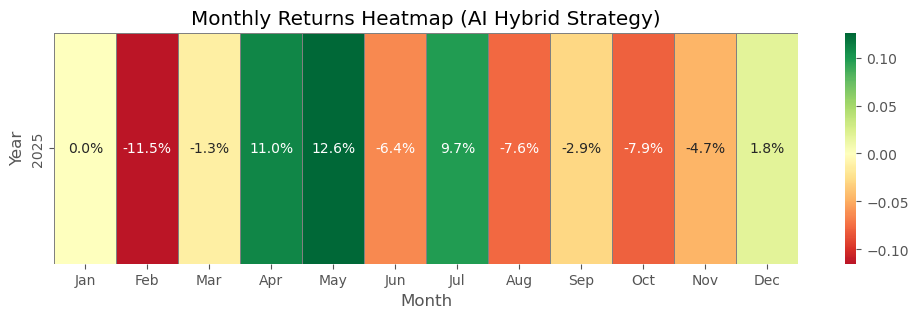

In [9]:
# --- Visualization 5: Monthly Returns Heatmap ---
hybrid_res_dt = hybrid_res.copy()
hybrid_res_dt.index = pd.to_datetime(hybrid_res_dt.index)

monthly_rets = hybrid_res_dt['Portfolio_Value'].resample('M').last().pct_change().fillna(0)
monthly_df = pd.DataFrame(monthly_rets)
monthly_df['Year'] = monthly_df.index.year
monthly_df['Month'] = monthly_df.index.strftime('%b')
monthly_df['Return'] = monthly_df['Portfolio_Value']

# Order months correctly
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_df['Month'] = pd.Categorical(monthly_df['Month'], categories=month_order, ordered=True)

pivot_table = monthly_df.pivot(index='Year', columns='Month', values='Return')

plt.figure(figsize=(12, 3))
sns.heatmap(pivot_table, annot=True, fmt='.1%', cmap='RdYlGn', center=0, cbar=True, linewidths=0.5, linecolor='gray')
plt.title('Monthly Returns Heatmap (AI Hybrid Strategy)')
plt.savefig('v42_monthly_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
